In [1]:
from os.path import isdir

from helpers.helpers import get_checkpoint_name_and_checkpoint_path
from helpers.embeddings import load_embeddings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sys
from os.path import abspath
nanogpt_path = abspath('../nanoGPT')
if not nanogpt_path in sys.path:
    sys.path.append(nanogpt_path)

from plots import plot_box

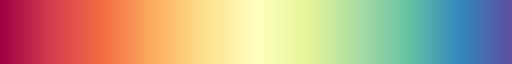

In [2]:
_cmap = plt.get_cmap('Spectral')
_cmap

In [3]:
cmap = _cmap(np.linspace(1, 0, 10)) # start with blue, end with red
len(cmap)

10

In [4]:
COLOR = plt.rcParams['axes.prop_cycle']
COLOR = [v for elem in list(COLOR) for _, v in elem.items()]
COLOR

['#0C5DA5', '#00B945', '#FF9500', '#FF2C00', '#845B97', '#474747', '#9e9e9e']

In [5]:
FIGURE_FORMAT = 'pdf'
# FIGURE_FORMAT = 'png'

In [6]:
LRS = [0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3]
MODEL_SIZES = ['4', '6', '8', 'A', 'C']
MODEL_SIZES_LABELS = [r'$16M$', r'$29M$', r'$57M$', r'$109M$', r'$221M$']

In [7]:
# PARAMETERS
WEIGHT_TYING = True
VARIANT_ANALYSIS = 'a' if WEIGHT_TYING is True else 'A'

WT = '.WT' if WEIGHT_TYING else ''

In [8]:
CHECKPOINT_DIRECTORY = '../checkpoints'
assert isdir(CHECKPOINT_DIRECTORY)

In [9]:
POSITIONS = ['output']

# 0. Get Checkpoint

In [10]:
DIVERGED = {
    'a': {
        '4': [False, False, False, False, False, True, True],
        '6': [False, False, False, False, False, True, True],
        '8': [False, False, False, False, True, True, True],
        'A': [False, False, False, False, False, True, True],
        'C': [False, False, False, False, True, True, True],
    }
}       

In [11]:
N = [
    '4', 
    '4', '4', '4', '4', '4', '4', '4',
    '6', '6', '6', '6', '6', '6', '6',
    '8', '8', '8', '8', '8', '8', '8',
    'A', 'A', 'A', 'A', 'A', 'A', 'A',
    'C', 'C', 'C', 'C', 'C', 'C', 'C',
]
D = 0
VARIANT = [
    'A', 
    'a', 'a', 'a', 'a', 'a', 'a', 'a',
    'a', 'a', 'a', 'a', 'a', 'a', 'a',
    'a', 'a', 'a', 'a', 'a', 'a', 'a',
    'a', 'a', 'a', 'a', 'a', 'a', 'a',
    'a', 'a', 'a', 'a', 'a', 'a', 'a',
]
GAMMA = '0e+00'
LR = [
    'lr10-', 
    'lr3-', 'lr10-', 'lr30-', 'lr100-', 'lr300-', 'lr1000-', 'lr3000-',
    'lr3-', 'lr10-', 'lr30-', 'lr100-', 'lr300-', 'lr1000-', 'lr3000-',
    'lr3-', 'lr10-', 'lr30-', 'lr100-', 'lr300-', 'lr1000-', 'lr3000-',
    'lr3-', 'lr10-', 'lr30-', 'lr100-', 'lr300-', 'lr1000-', 'lr3000-',
    'lr3-', 'lr10-', 'lr30-', 'lr100-', 'lr300-', 'lr1000-', 'lr3000-',
]
CHECKPOINT = 'ckpt_100000'

In [12]:
N0 = N[0]
VARIANT0 = VARIANT[0]
LR0 = LR[0]

In [13]:
if VARIANT0 == 'A':
    limnorm = [-2, 5]
elif VARIANT0 == 'a':
    limnorm = [-20, 100]
else:
    raise Exception()

In [14]:
checkpoint_names, checkpoint_paths = {}, {}

for i, (n, variant, lr) in enumerate(zip(N, VARIANT, LR)):
    checkpoint_names[(n,variant,lr)], checkpoint_paths[(n,variant,lr)] = get_checkpoint_name_and_checkpoint_path(
        CHECKPOINT_DIRECTORY, n, D, variant, lr, GAMMA, CHECKPOINT
    )
    if i == 0:
        KEY0 = (n, variant, lr)
KEYS = list(checkpoint_names.keys())

# checkpoint_names, checkpoint_paths, KEY0, KEYS

In [15]:
KEYS

[('4', 'A', 'lr10-'),
 ('4', 'a', 'lr3-'),
 ('4', 'a', 'lr10-'),
 ('4', 'a', 'lr30-'),
 ('4', 'a', 'lr100-'),
 ('4', 'a', 'lr300-'),
 ('4', 'a', 'lr1000-'),
 ('4', 'a', 'lr3000-'),
 ('6', 'a', 'lr3-'),
 ('6', 'a', 'lr10-'),
 ('6', 'a', 'lr30-'),
 ('6', 'a', 'lr100-'),
 ('6', 'a', 'lr300-'),
 ('6', 'a', 'lr1000-'),
 ('6', 'a', 'lr3000-'),
 ('8', 'a', 'lr3-'),
 ('8', 'a', 'lr10-'),
 ('8', 'a', 'lr30-'),
 ('8', 'a', 'lr100-'),
 ('8', 'a', 'lr300-'),
 ('8', 'a', 'lr1000-'),
 ('8', 'a', 'lr3000-'),
 ('A', 'a', 'lr3-'),
 ('A', 'a', 'lr10-'),
 ('A', 'a', 'lr30-'),
 ('A', 'a', 'lr100-'),
 ('A', 'a', 'lr300-'),
 ('A', 'a', 'lr1000-'),
 ('A', 'a', 'lr3000-'),
 ('C', 'a', 'lr3-'),
 ('C', 'a', 'lr10-'),
 ('C', 'a', 'lr30-'),
 ('C', 'a', 'lr100-'),
 ('C', 'a', 'lr300-'),
 ('C', 'a', 'lr1000-'),
 ('C', 'a', 'lr3000-')]

# 1. Load Embeddings

### a. Embeddings

In [16]:
OVERWRITE = False

In [17]:
embeddings = {
    k: load_embeddings(
        checkpoint_paths[k], 
        checkpoint_names[k], 
        positions=POSITIONS, 
        overwrite=OVERWRITE,
    )
    for k in KEYS
}

> loaded embeddings for wor40A-16M-13p1B-100k-bs64-lr10-baseline-g0e+00-s1
.. position = output, embeddings[position].shape = (50304, 224)
> loaded embeddings for wor40a-16M-13p1B-100k-bs64-lr3-baselinewt-g0e+00-s1
.. position = output, embeddings[position].shape = (50304, 224)
> loaded embeddings for wor40a-16M-13p1B-100k-bs64-lr10-baselinewt-g0e+00-s1
.. position = output, embeddings[position].shape = (50304, 224)
> loaded embeddings for wor40a-16M-13p1B-100k-bs64-lr30-baselinewt-g0e+00-s1
.. position = output, embeddings[position].shape = (50304, 224)
> loaded embeddings for wor40a-16M-13p1B-100k-bs64-lr100-baselinewt-g0e+00-s1
.. position = output, embeddings[position].shape = (50304, 224)
> loaded embeddings for wor40a-16M-13p1B-100k-bs64-lr300-baselinewt-g0e+00-s1
.. position = output, embeddings[position].shape = (50304, 224)
> loaded embeddings for wor40a-16M-13p1B-100k-bs64-lr1000-baselinewt-g0e+00-s1
.. position = output, embeddings[position].shape = (50304, 224)
> loaded emb

# 2. Analysis: Components Parallel & Perpendicular To Mean Embedding

### a. Embeddings

In [18]:
embeddings[KEY0].keys()

dict_keys(['output'])

In [19]:
E = {k: embeddings[k]['output'] for k in KEYS}
E[KEY0].shape

(50304, 224)

In [20]:
mu = {k: np.mean(E[k], axis=0, keepdims=True).T for k in KEYS}
mu[KEY0]

array([[-6.64824573e-03],
       [-5.74734844e-02],
       [-1.99278016e-02],
       [-1.58791974e-01],
       [ 1.41235394e-02],
       [-4.96235152e-04],
       [-9.13657155e-03],
       [-9.53724012e-02],
       [ 5.76304831e-03],
       [ 9.58352163e-03],
       [-5.54444909e-01],
       [ 1.37564505e-03],
       [ 3.36151570e-02],
       [-1.28376707e-02],
       [ 4.89597470e-02],
       [ 1.17973844e-02],
       [-8.66095629e-03],
       [-4.65476885e-03],
       [ 1.55947441e-02],
       [ 2.56573576e-02],
       [-2.87008341e-02],
       [ 3.60521004e-02],
       [ 4.06100124e-04],
       [ 1.67929046e-02],
       [-2.31193788e-02],
       [ 1.19642224e-02],
       [ 1.30905332e-02],
       [ 2.61728019e-01],
       [-1.93012282e-02],
       [ 7.56400917e-03],
       [-2.68195160e-02],
       [ 9.40689519e-02],
       [ 2.94572581e-02],
       [ 2.23866403e-02],
       [-1.33088892e-02],
       [ 4.42997552e-02],
       [-7.39623904e-02],
       [-8.99774896e-04],
       [ 7.5

### b. 1D histogram: dot products unnormalized

### b'. 1D histogram: dot products normalized

### c. 2D histogram: dot products normalized & perpendicular norm

### c'. 2D histogram: dot products normalized & perpendicular norm (all)

### d. correlation

### e. max - min

#### dotshat_maxmin

#### dotshat_centered

# 3. Analysis: Embedding Norm Distribution

In [21]:
E[KEY0].shape

(50304, 224)

In [22]:
Estar = {k: E[k] - mu[k].T for k in KEYS}
Estar[KEY0].shape

(50304, 224)

In [23]:
norm_E = {k: np.linalg.norm(E[k], axis=1, keepdims=False) for k in KEYS}
norm_E[KEY0].shape

(50304,)

In [24]:
norm_Estar = {k: np.linalg.norm(Estar[k], axis=1, keepdims=False) for k in KEYS}
norm_Estar[KEY0].shape

(50304,)

In [25]:
norm_mu = {k: np.linalg.norm(mu[k]) for k in KEYS}
norm_mu[KEY0]

np.float32(2.212258)

In [26]:
norm_ratio = {k: norm_Estar[k] / norm_E[k] for k in KEYS}
norm_ratio[KEY0].shape

(50304,)

In [27]:
norm_ratio_max = {k: float(np.max(norm_Estar[k]) / np.max(norm_E[k])) for k in KEYS}
norm_ratio_max

{('4', 'A', 'lr10-'): 0.8640042543411255,
 ('4', 'a', 'lr3-'): 1.1686785221099854,
 ('4', 'a', 'lr10-'): 0.854701042175293,
 ('4', 'a', 'lr30-'): 0.8790827393531799,
 ('4', 'a', 'lr100-'): 0.8091112971305847,
 ('4', 'a', 'lr300-'): 0.7795553803443909,
 ('4', 'a', 'lr1000-'): 0.6319960355758667,
 ('4', 'a', 'lr3000-'): 0.716056764125824,
 ('6', 'a', 'lr3-'): 1.147640585899353,
 ('6', 'a', 'lr10-'): 1.0195112228393555,
 ('6', 'a', 'lr30-'): 0.7569611072540283,
 ('6', 'a', 'lr100-'): 0.9017326831817627,
 ('6', 'a', 'lr300-'): 0.6238654851913452,
 ('6', 'a', 'lr1000-'): 0.7140173316001892,
 ('6', 'a', 'lr3000-'): 0.7870280742645264,
 ('8', 'a', 'lr3-'): 1.295312523841858,
 ('8', 'a', 'lr10-'): 0.8917801976203918,
 ('8', 'a', 'lr30-'): 0.8998100161552429,
 ('8', 'a', 'lr100-'): 0.8252252340316772,
 ('8', 'a', 'lr300-'): 0.732255220413208,
 ('8', 'a', 'lr1000-'): 0.7415053248405457,
 ('8', 'a', 'lr3000-'): 0.7251666188240051,
 ('A', 'a', 'lr3-'): 1.167507529258728,
 ('A', 'a', 'lr10-'): 0.85

In [28]:
norm_df = {k: pd.DataFrame({'E': norm_E[k], 'Estar': norm_Estar[k], 'model_size': k[0], 'lr': int(k[2][2:][:-1])}) for k in KEYS}
norm_df[KEY0].describe()

,E,Estar,lr
count,50304.000000,50304.000000,50304.0
mean,2.435182,1.167866,10.0
std,0.698566,0.400187,0.0
min,0.901311,0.435747,10.0
25%,1.942186,0.874428,10.0
50%,2.350407,1.086034,10.0
75%,2.897092,1.370839,10.0
max,4.758293,4.111186,10.0


In [29]:
def ratio(_input):
    _Estar, _E = _input
    return _Estar / _E

df_all = pd.concat(list(norm_df.values()), ignore_index=True)
df_all['Estar/E'] = df_all[['Estar', 'E']].apply(lambda x: ratio(x), axis=1) 
df_all

,E,Estar,model_size,lr,Estar/E
0,1.341256,2.603530,4,10,1.941114
1,1.578883,2.279780,4,10,1.443920
2,1.617816,1.175507,4,10,0.726601
3,1.711457,1.153476,4,10,0.673973
4,1.543737,1.565484,4,10,1.014087
...,...,...,...,...,...
1810939,627.424927,248.471481,C,3000,0.396018
1810940,627.427551,248.470779,C,3000,0.396015
1810941,627.427979,248.467422,C,3000,0.396009
1810942,627.432129,248.472626,C,3000,0.396015


### Grid Plots

### Percentage

In [30]:
LR_MAPPING = {
    '3': 0.0003,
    '10': 0.001,
    '30': 0.003,
    '100': 0.01,
    '300': 0.03,
    '1000': 0.1,
    '3000': 0.3,
}
LR_MAPPING_INVERSE = {v: k for k, v in LR_MAPPING.items()}

In [31]:
LABELS = [(k[0], k[2].split('lr')[-1].split('-')[0]) for k in norm_ratio_max.keys() if k[1] == VARIANT_ANALYSIS]
LABELS

[('4', '3'),
 ('4', '10'),
 ('4', '30'),
 ('4', '100'),
 ('4', '300'),
 ('4', '1000'),
 ('4', '3000'),
 ('6', '3'),
 ('6', '10'),
 ('6', '30'),
 ('6', '100'),
 ('6', '300'),
 ('6', '1000'),
 ('6', '3000'),
 ('8', '3'),
 ('8', '10'),
 ('8', '30'),
 ('8', '100'),
 ('8', '300'),
 ('8', '1000'),
 ('8', '3000'),
 ('A', '3'),
 ('A', '10'),
 ('A', '30'),
 ('A', '100'),
 ('A', '300'),
 ('A', '1000'),
 ('A', '3000'),
 ('C', '3'),
 ('C', '10'),
 ('C', '30'),
 ('C', '100'),
 ('C', '300'),
 ('C', '1000'),
 ('C', '3000')]

In [32]:
QUANTITIES_SPECIAL = ['Estar/E']

In [33]:
percentage = {k: {} for k in QUANTITIES_SPECIAL}
df_all['percentage_Estar/E'] = df_all['Estar/E'].apply(lambda x: x < 1)
for label in LABELS:
    _df = df_all[df_all['model_size'] == label[0]]
    _df = _df[_df['lr'] == int(label[1])]
    percentage['Estar/E'][(label[0], LR_MAPPING[label[1]])] = float(_df['percentage_Estar/E'].mean())

percentage

{'Estar/E': {('4', 0.0003): 0.9392294847328244,
  ('4', 0.001): 0.9492883269720102,
  ('4', 0.003): 0.9361084605597965,
  ('4', 0.01): 0.9501431297709924,
  ('4', 0.03): 0.9595658396946565,
  ('4', 0.1): 0.9704794847328244,
  ('4', 0.3): 0.9501630089058524,
  ('6', 0.0003): 0.93748012086514,
  ('6', 0.001): 0.9435631361323156,
  ('6', 0.003): 0.9386927480916031,
  ('6', 0.01): 0.9481154580152672,
  ('6', 0.03): 0.9703602099236641,
  ('6', 0.1): 0.9466245229007634,
  ('6', 0.3): 0.9629850508905853,
  ('8', 0.0003): 0.9276995865139949,
  ('8', 0.001): 0.9422709923664122,
  ('8', 0.003): 0.9390903307888041,
  ('8', 0.01): 0.9421517175572519,
  ('8', 0.03): 0.9690283078880407,
  ('8', 0.1): 0.9240815839694656,
  ('8', 0.3): 0.9338024809160306,
  ('A', 0.0003): 0.9372813295165394,
  ('A', 0.001): 0.9215768129770993,
  ('A', 0.003): 0.9416149809160306,
  ('A', 0.01): 0.9376192748091603,
  ('A', 0.03): 0.9587507951653944,
  ('A', 0.1): 0.9461474236641222,
  ('A', 0.3): 0.9594863231552163,
  (

In [34]:
df_all_float = df_all.copy()
df_all_float['lr'] = df_all_float['lr'].apply(lambda x: x/10000.)
df_all_float

,E,Estar,model_size,lr,Estar/E,percentage_Estar/E
0,1.341256,2.603530,4,0.001,1.941114,False
1,1.578883,2.279780,4,0.001,1.443920,False
2,1.617816,1.175507,4,0.001,0.726601,True
3,1.711457,1.153476,4,0.001,0.673973,True
4,1.543737,1.565484,4,0.001,1.014087,False
...,...,...,...,...,...,...
1810939,627.424927,248.471481,C,0.300,0.396018,True
1810940,627.427551,248.470779,C,0.300,0.396015,True
1810941,627.427979,248.467422,C,0.300,0.396009,True
1810942,627.432129,248.472626,C,0.300,0.396015,True


### Box Plots

> saved as figs/stats.Estar_E.WT.pdf


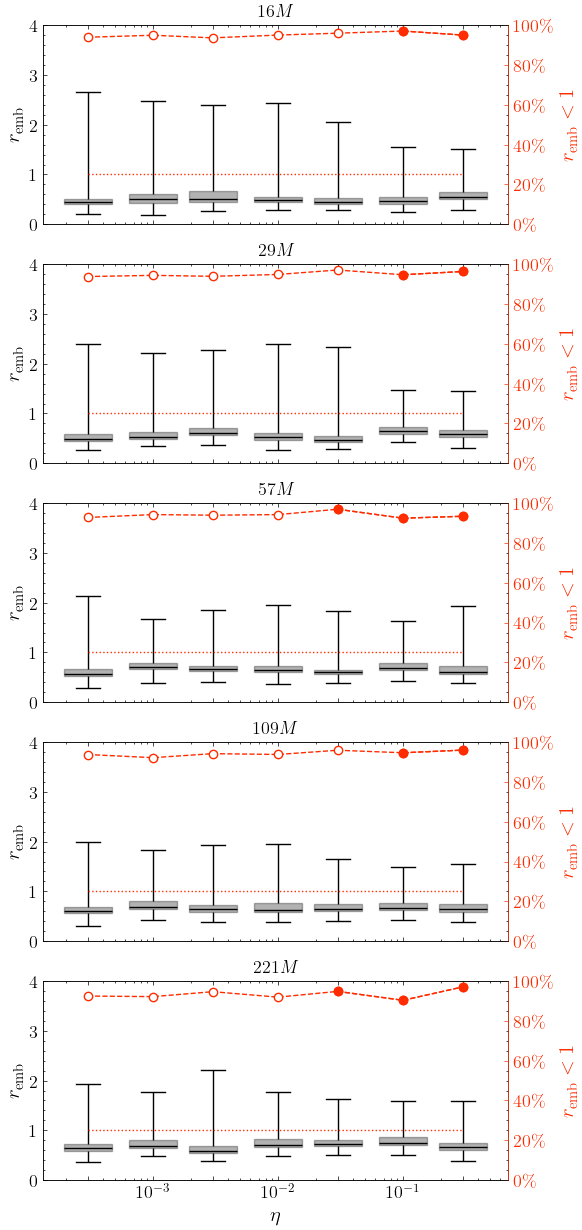

In [35]:
plot_box(
    LRS,
    'Estar/E', 
    percentage,
    MODEL_SIZES, 
    MODEL_SIZES_LABELS, 
    r'$r_{\rm emb}$', 
    r'$r_{\rm emb} < 1$', 
    df_all_float,
    diverged=DIVERGED[VARIANT_ANALYSIS],
    save_as=f'stats.Estar_E{WT}.{FIGURE_FORMAT}',
)